In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

In [ ]:
df=pd.read_csv("diabetes.csv")

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
zero_columns = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
print((df[zero_columns]==0).sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [ ]:
df_clean = df.copy()

df_clean[zero_columns] = df_clean[zero_columns].replace(0,np.nan)
print("\nMissing values after replacing zeros:")
print(df_clean.isnull().sum())


Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
#Median Imputation
imputer = SimpleImputer(strategy='median')

df_clean[zero_columns] = imputer.fit_transform(
    df_clean[zero_columns]
)

print("\nMissing values after imputation:")
print(df_clean.isnull().sum())



Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
correlation_matrix = df_clean.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.128213       0.208615       0.081770   
Glucose                      0.128213  1.000000       0.218937       0.192615   
BloodPressure                0.208615  0.218937       1.000000       0.191892   
SkinThickness                0.081770  0.192615       0.191892       1.000000   
Insulin                      0.025047  0.419451       0.045363       0.155610   
BMI                          0.021559  0.231049       0.281257       0.543205   
DiabetesPedigreeFunction    -0.033523  0.137327      -0.002378       0.102188   
Age                          0.544341  0.266909       0.324915       0.126107   
Outcome                      0.221898  0.492782       0.165723       0.214873   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.025047  0.021559                 -0.033523   
Glucose             

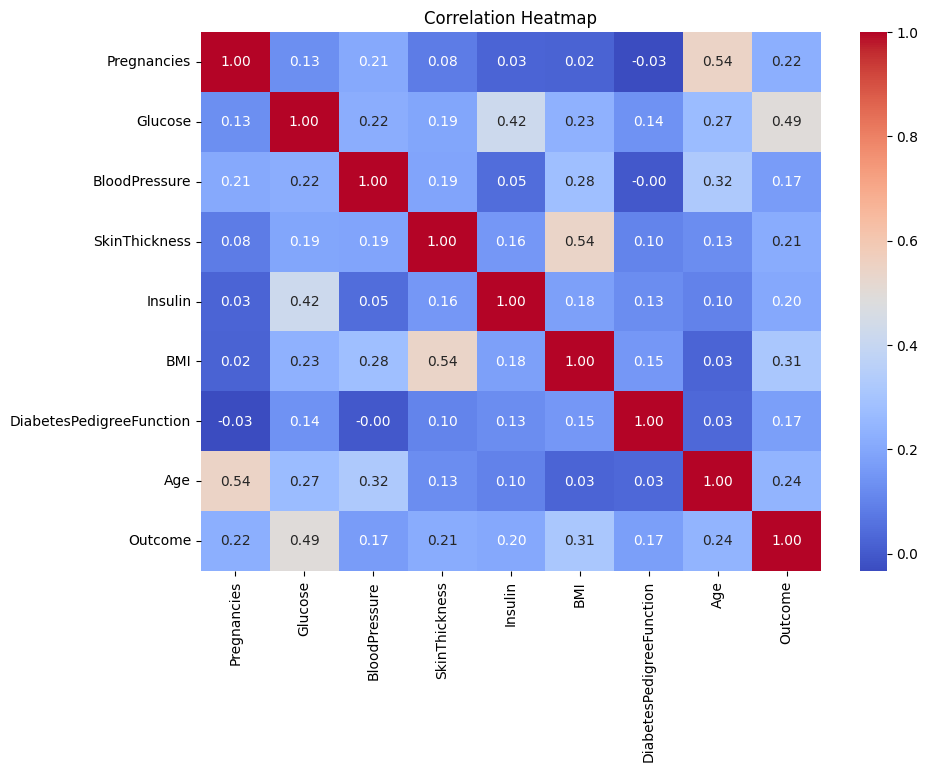

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = df_clean.drop('Outcome', axis=1)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

In [ ]:
obs1 = X_scaled.iloc[0].values.reshape(1, -1)
obs2 = X_scaled.iloc[1].values.reshape(1, -1)

In [ ]:
euclidean = pairwise_distances(
    obs1, obs2, metric='euclidean'
)[0][0]

In [ ]:
manhattan = pairwise_distances(
    obs1, obs2, metric='manhattan'
)[0][0]

In [ ]:
cosine = pairwise_distances(
    obs1, obs2, metric='cosine'
)[0][0]

In [ ]:
print("\nDistance Measures:")
print("Euclidean Distance:", euclidean)
print("Manhattan Distance:", manhattan)
print("Cosine Distance:", cosine)


Distance Measures:
Euclidean Distance: 3.3990287229648346
Manhattan Distance: 8.204254584712945
Cosine Distance: 1.584724621169475
